# Clean Experimentation Visualization

This notebook is a clean visualization-first summary of the experimentation work from Deliverable 3.

It focuses on:
- what ideas we tested
- how the experiments evolved
- which plots best show the results

It is meant to be presentation-friendly and does not rerun the heavy modeling pipeline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = next((path for path in CANDIDATE_ROOTS if (path / "Deliverable3").exists()), Path.cwd())
if REPO_ROOT.name == "Deliverable3":
    REPO_ROOT = REPO_ROOT.parent

OUTPUT_DIR = REPO_ROOT / "Deliverable3" / "experiment_outputs"

def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / name)

def annotate_bar_values(ax, fmt: str = "{:.3f}"):
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append(fmt.format(height) if pd.notna(height) else "")
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

print("REPO_ROOT:", REPO_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


REPO_ROOT: c:\Users\Vido\Desktop\GitHubRepository\EPL448TeamProject
OUTPUT_DIR: c:\Users\Vido\Desktop\GitHubRepository\EPL448TeamProject\Deliverable3\experiment_outputs


## Experiment Story

The experimentation story is organized into five themes:

1. Baseline model comparison and early feature add-backs.
2. Early diagnostics for modeling: correlation and skewness.
3. Larger-sample and stronger-model comparisons.
4. Clean safe non-proxy feature selection.
5. Final clean-model refinements and ablations.


## 1. Baseline Stages And Add-Back Experiments

These plots show the early progression from the clean baseline into add-back and engineered-feature stages.

,stage,dataset_version,model,weighted_f1_mean,precision_mean,recall_mean
0,clean_baseline,without_state,logistic_regression,0.652960,0.653959,0.650728
1,fico_add_back,without_state,logistic_regression,0.653780,0.654511,0.652330
2,fico_plus_proxy_add_back,without_state,logistic_regression,0.664813,0.661618,0.675732
3,engineered_features,without_state,logistic_regression,0.666233,0.663506,0.675330
4,skew_adjusted_features,without_state,logistic_regression,0.663349,0.660477,0.672932


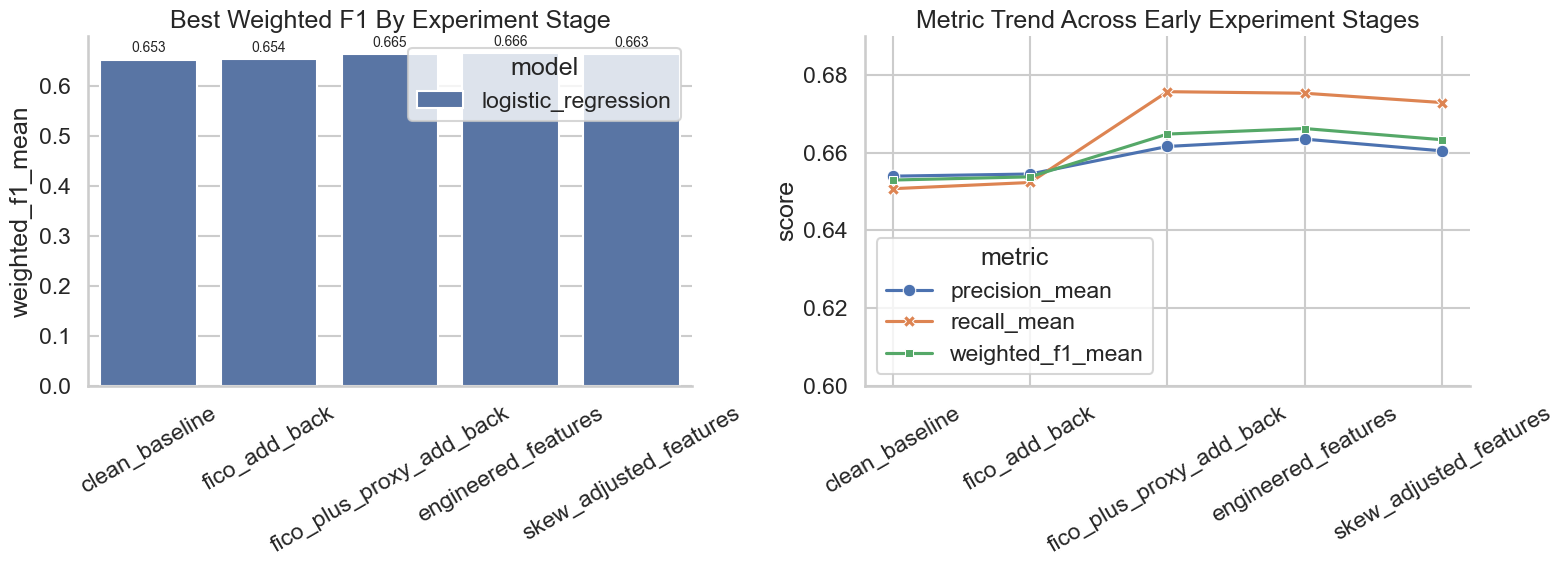

In [2]:
stage_specs = [
    ("clean_baseline", "initial_cv_summary.csv"),
    ("fico_add_back", "initial_cv_summary_addback_fico_ranges.csv"),
    ("fico_plus_proxy_add_back", "initial_cv_summary_addback_fico_grade_subgrade_int_rate_installment.csv"),
    ("engineered_features", "initial_cv_summary_engineered_features.csv"),
    ("skew_adjusted_features", "initial_cv_summary_skew_adjusted_features.csv"),
]

stage_rows = []
for stage_name, file_name in stage_specs:
    stage_df = load_csv(file_name).copy()
    best_row = stage_df.sort_values(["weighted_f1_mean", "recall_mean", "precision_mean"], ascending=[False, False, False]).iloc[0]
    stage_rows.append({
        "stage": stage_name,
        "dataset_version": best_row["dataset_version"],
        "model": best_row["model"],
        "weighted_f1_mean": best_row["weighted_f1_mean"],
        "precision_mean": best_row["precision_mean"],
        "recall_mean": best_row["recall_mean"],
    })

stage_progress_df = pd.DataFrame(stage_rows)
display(stage_progress_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=stage_progress_df, x="stage", y="weighted_f1_mean", hue="model", ax=axes[0])
axes[0].set_title("Best Weighted F1 By Experiment Stage")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
annotate_bar_values(axes[0])

metric_long_df = stage_progress_df.melt(
    id_vars=["stage", "model"],
    value_vars=["precision_mean", "recall_mean", "weighted_f1_mean"],
    var_name="metric",
    value_name="score",
)
sns.lineplot(data=metric_long_df, x="stage", y="score", hue="metric", style="metric", markers=True, dashes=False, ax=axes[1])
axes[1].set_title("Metric Trend Across Early Experiment Stages")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylim(0.60, 0.69)

plt.tight_layout()
plt.show()


## 2. Early Diagnostics: Correlation And Skewness

These plots show the correlation experiments and skewness checks that were explored early in the modeling process.

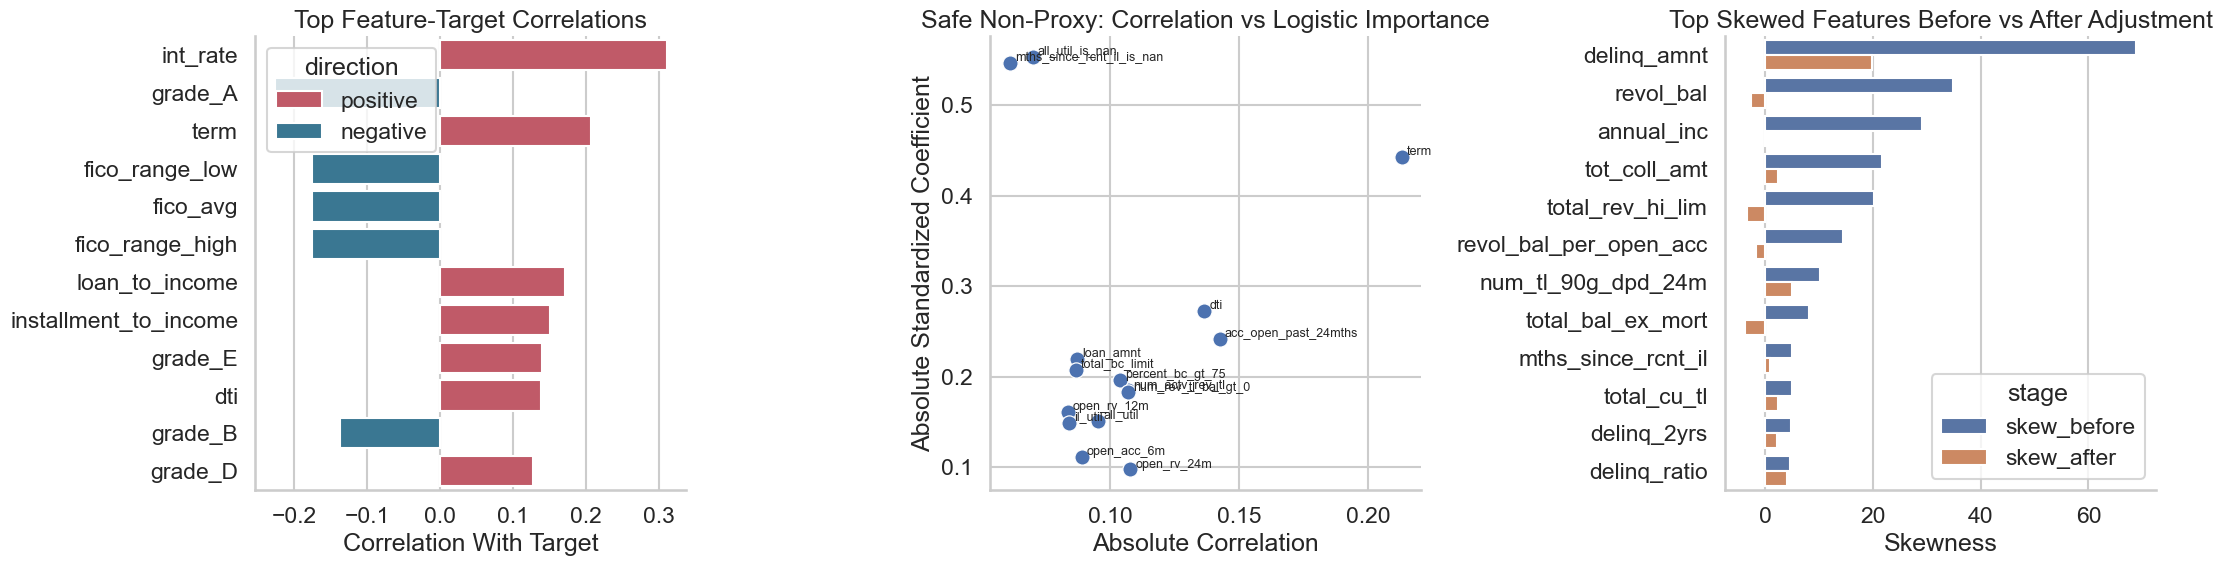

In [3]:
feature_corr_df = load_csv("feature_target_correlations_large_sample_without_state.csv").head(12).copy()
safe_rank_df = load_csv("safe_non_proxy_feature_ranking_clean_baseline.csv").copy()
safe_rank_top = safe_rank_df.head(15).copy()
safe_rank_top["label"] = safe_rank_top["feature"]
skew_df = load_csv("skewness_report_skew_adjusted_features.csv").head(12).copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=feature_corr_df, y="feature", x="correlation_with_target", hue="direction", dodge=False, palette={"positive": "#d1495b", "negative": "#2c7da0"}, ax=axes[0])
axes[0].set_title("Top Feature-Target Correlations")
axes[0].set_xlabel("Correlation With Target")
axes[0].set_ylabel("")

sns.scatterplot(data=safe_rank_top, x="abs_correlation", y="abs_standardized_coefficient", s=120, ax=axes[1])
for _, row in safe_rank_top.iterrows():
    axes[1].text(row["abs_correlation"] + 0.002, row["abs_standardized_coefficient"] + 0.002, row["label"], fontsize=9)
axes[1].set_title("Safe Non-Proxy: Correlation vs Logistic Importance")
axes[1].set_xlabel("Absolute Correlation")
axes[1].set_ylabel("Absolute Standardized Coefficient")

skew_plot_df = skew_df.melt(id_vars=["feature"], value_vars=["skew_before", "skew_after"], var_name="stage", value_name="skew")
sns.barplot(data=skew_plot_df, y="feature", x="skew", hue="stage", ax=axes[2])
axes[2].set_title("Top Skewed Features Before vs After Adjustment")
axes[2].set_xlabel("Skewness")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


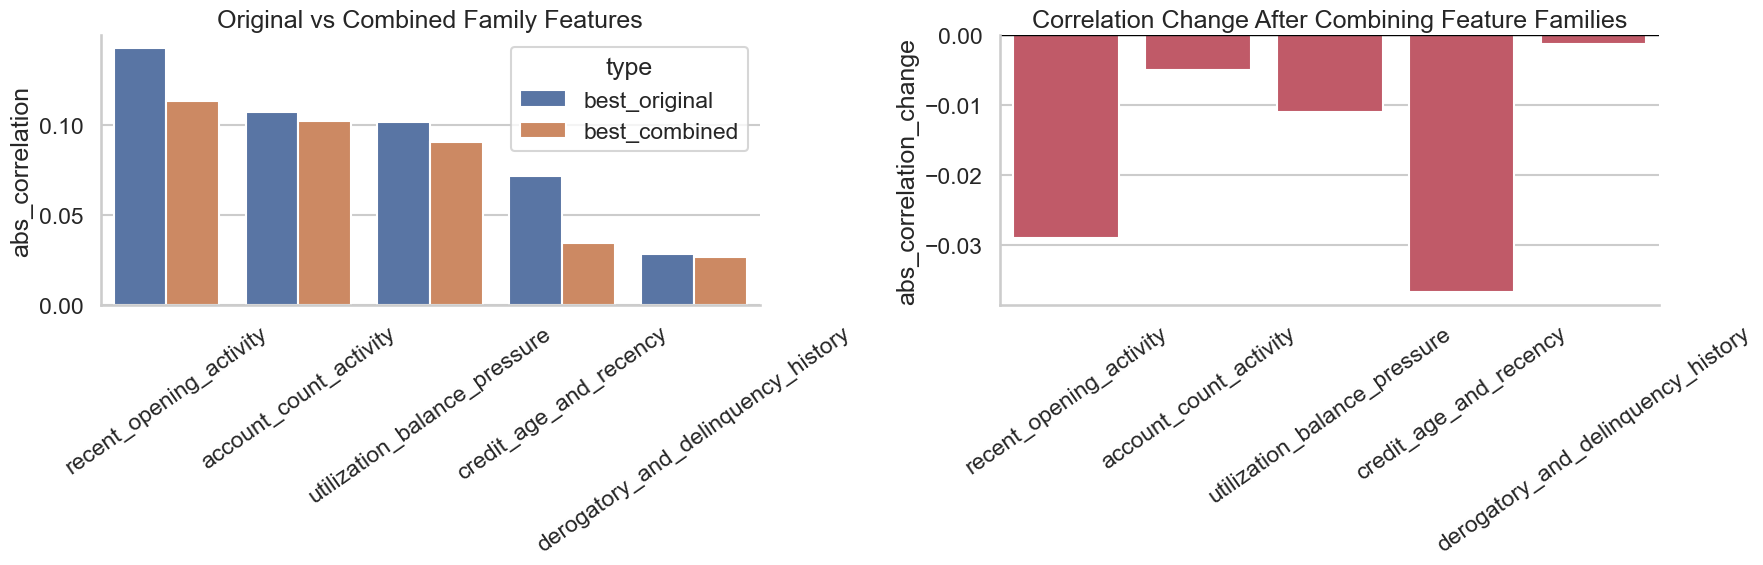

In [4]:
family_summary_df = load_csv("safe_non_proxy_family_combined_summary_clean_baseline.csv").copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

comparison_long_df = pd.DataFrame({
    "family": list(family_summary_df["family"]) * 2,
    "type": ["best_original"] * len(family_summary_df) + ["best_combined"] * len(family_summary_df),
    "abs_correlation": list(family_summary_df["best_original_abs_correlation"]) + list(family_summary_df["best_combined_abs_correlation"]),
})
sns.barplot(data=comparison_long_df, x="family", y="abs_correlation", hue="type", ax=axes[0])
axes[0].set_title("Original vs Combined Family Features")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=family_summary_df, x="family", y="abs_correlation_change", color="#d1495b", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Correlation Change After Combining Feature Families")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


## 3. Larger-Sample And Stronger-Model Comparisons

These plots summarize the shift from simple baselines to boosted-tree and native categorical models.

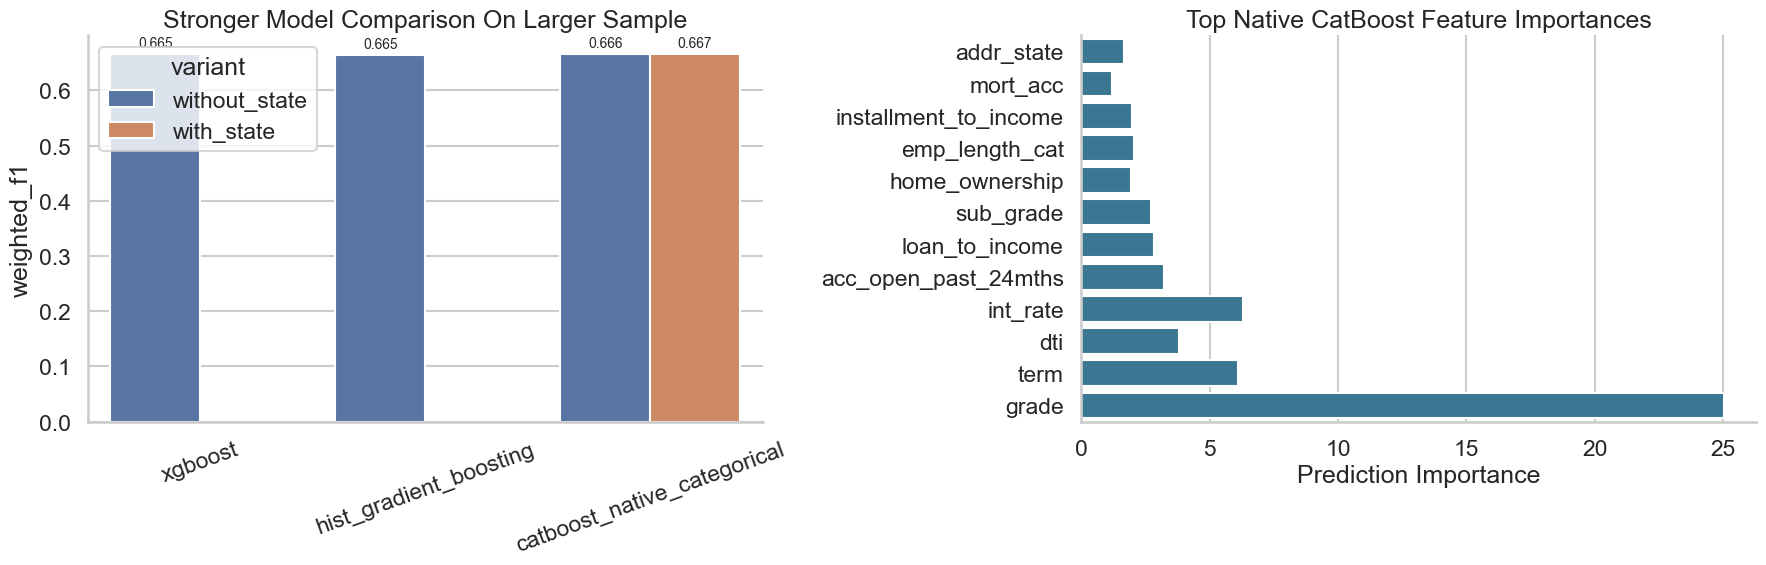

In [5]:
boosted_df = load_csv("boosted_tree_comparison_large_sample_summary.csv").copy()
catboost_native_df = load_csv("catboost_native_large_sample_summary.csv").copy()
native_importance_df = load_csv("catboost_native_feature_importance_large_sample.csv").head(12).copy()

comparison_models_df = pd.DataFrame([
    {"model": "xgboost", "variant": "without_state", "weighted_f1": float(boosted_df.loc[boosted_df["model"] == "xgboost", "weighted_f1_mean"].iloc[0])},
    {"model": "hist_gradient_boosting", "variant": "without_state", "weighted_f1": float(boosted_df.loc[boosted_df["model"] == "hist_gradient_boosting", "weighted_f1_mean"].iloc[0])},
    {"model": "catboost_native_categorical", "variant": "with_state", "weighted_f1": float(catboost_native_df.loc[catboost_native_df["dataset_version"] == "with_state", "best_weighted_f1"].iloc[0])},
    {"model": "catboost_native_categorical", "variant": "without_state", "weighted_f1": float(catboost_native_df.loc[catboost_native_df["dataset_version"] == "without_state", "best_weighted_f1"].iloc[0])},
])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=comparison_models_df, x="model", y="weighted_f1", hue="variant", ax=axes[0])
axes[0].set_title("Stronger Model Comparison On Larger Sample")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
annotate_bar_values(axes[0])

native_importance_plot_df = native_importance_df.sort_values("combined_rank", ascending=False)
sns.barplot(data=native_importance_plot_df, y="feature", x="prediction_importance", color="#2c7da0", ax=axes[1])
axes[1].set_title("Top Native CatBoost Feature Importances")
axes[1].set_xlabel("Prediction Importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 4. Clean Safe Non-Proxy Feature Selection

These plots show how the clean safe non-proxy path was narrowed down into final ranked subsets.

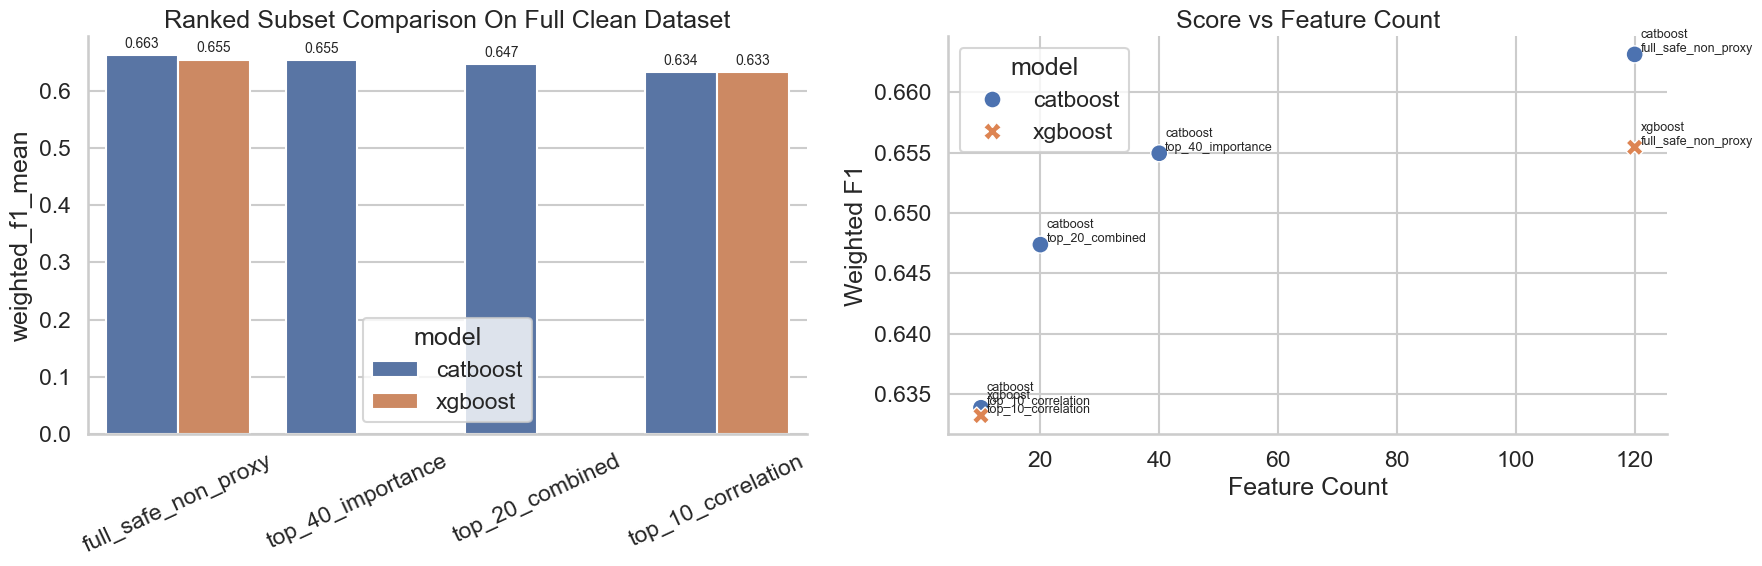

In [6]:
ranked_subset_df = load_csv("selected_ranked_subsets_full_clean_baseline_summary.csv").copy()
ranked_subset_df = ranked_subset_df[ranked_subset_df["subset_name"].isin(["top_10_correlation", "top_20_combined", "top_40_importance", "full_safe_non_proxy"])]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=ranked_subset_df, x="subset_name", y="weighted_f1_mean", hue="model", ax=axes[0])
axes[0].set_title("Ranked Subset Comparison On Full Clean Dataset")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)
annotate_bar_values(axes[0])

sns.scatterplot(data=ranked_subset_df, x="feature_count", y="weighted_f1_mean", hue="model", style="model", s=150, ax=axes[1])
for _, row in ranked_subset_df.iterrows():
    axes[1].text(row["feature_count"] + 1, row["weighted_f1_mean"] + 0.0002, f"{row['model']}\n{row['subset_name']}", fontsize=9)
axes[1].set_title("Score vs Feature Count")
axes[1].set_xlabel("Feature Count")
axes[1].set_ylabel("Weighted F1")

plt.tight_layout()
plt.show()


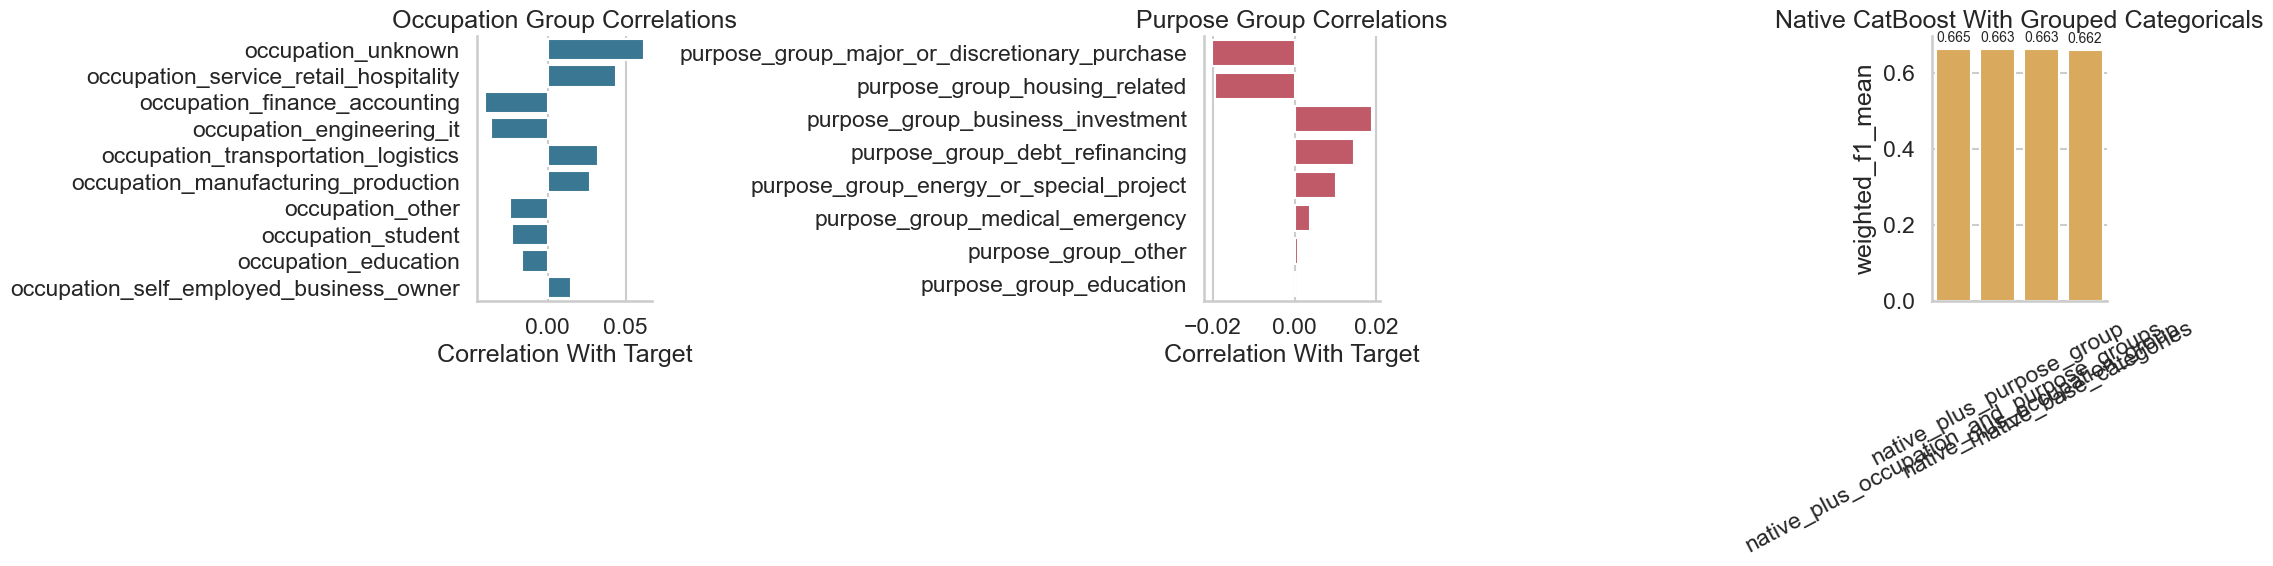

In [7]:
occupation_corr_df = load_csv("occupation_group_correlations_clean_baseline.csv").head(10).copy()
purpose_corr_df = load_csv("purpose_group_correlations_clean_baseline.csv").copy()
native_grouped_variants_df = load_csv("native_grouped_catboost_full_clean_summary.csv").copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=occupation_corr_df, y="feature", x="correlation_with_target", color="#2c7da0", ax=axes[0])
axes[0].set_title("Occupation Group Correlations")
axes[0].set_xlabel("Correlation With Target")
axes[0].set_ylabel("")

sns.barplot(data=purpose_corr_df, y="feature", x="correlation_with_target", color="#d1495b", ax=axes[1])
axes[1].set_title("Purpose Group Correlations")
axes[1].set_xlabel("Correlation With Target")
axes[1].set_ylabel("")

sns.barplot(data=native_grouped_variants_df, x="variant", y="weighted_f1_mean", color="#edae49", ax=axes[2])
axes[2].set_title("Native CatBoost With Grouped Categoricals")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=28)
annotate_bar_values(axes[2])

plt.tight_layout()
plt.show()


## 5. Final Clean-Model Refinements And Ablations

These plots summarize the final four clean models and the last ablation checks.

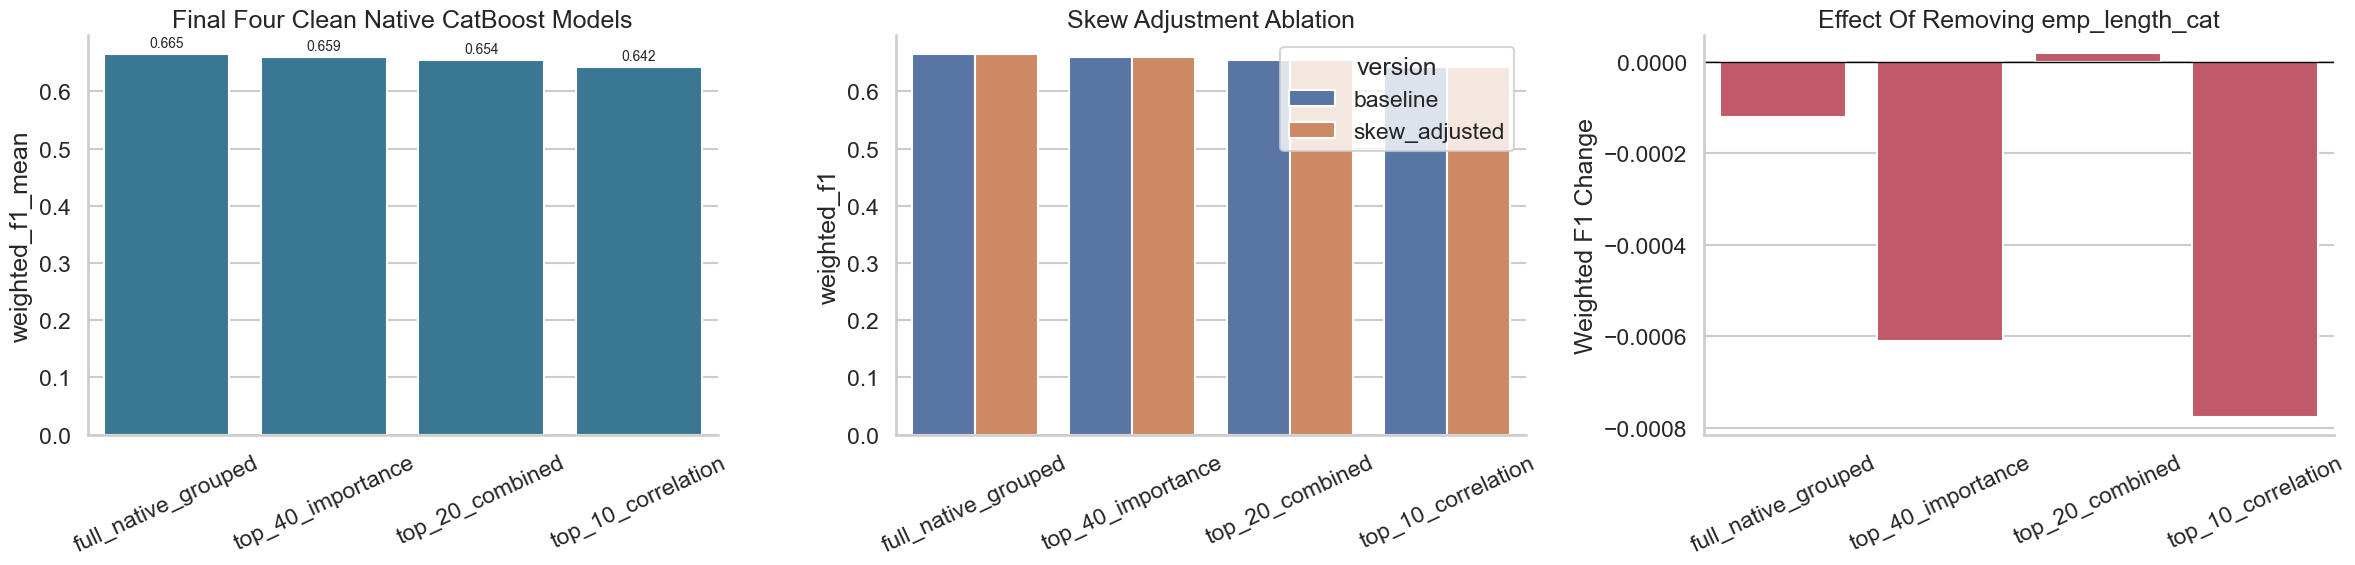

In [8]:
final_four_df = load_csv("native_grouped_catboost_ranked_subsets_full_clean_summary.csv").copy()
skew_ablation_df = load_csv("native_grouped_catboost_ranked_subsets_full_clean_skew_summary.csv").copy()
no_emp_cat_df = load_csv("native_grouped_catboost_ranked_subsets_full_clean_no_emp_length_cat_comparison.csv").copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(data=final_four_df, x="subset_name", y="weighted_f1_mean", color="#2c7da0", ax=axes[0])
axes[0].set_title("Final Four Clean Native CatBoost Models")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)
annotate_bar_values(axes[0])

skew_compare_df = final_four_df[["subset_name", "weighted_f1_mean"]].rename(columns={"weighted_f1_mean": "baseline"}).merge(
    skew_ablation_df[["subset_name", "weighted_f1_mean"]].rename(columns={"weighted_f1_mean": "skew_adjusted"}),
    on="subset_name",
)
skew_compare_long_df = skew_compare_df.melt(id_vars=["subset_name"], value_vars=["baseline", "skew_adjusted"], var_name="version", value_name="weighted_f1")
sns.barplot(data=skew_compare_long_df, x="subset_name", y="weighted_f1", hue="version", ax=axes[1])
axes[1].set_title("Skew Adjustment Ablation")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=no_emp_cat_df, x="subset_name", y="weighted_f1_change", color="#d1495b", ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Effect Of Removing emp_length_cat")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=25)
axes[2].set_ylabel("Weighted F1 Change")

plt.tight_layout()
plt.show()


## Quick Takeaways

- Early add-backs and engineering improved the baseline story more than simple skew fixes.
- Correlation and importance analyses were useful for understanding features, even when the full clean set still performed best.
- Native categorical `CatBoost` became the strongest family for the clean safe non-proxy path.
- The final clean four-model comparison is clear and visually compact: `full_native_grouped` wins, while `top_40_importance` is the best compact alternative.
- The final ablations show that skew adjustment and removing `emp_length_cat` did not improve the best clean model.
